# 04 — Prévision J+1 (baseline linéaire + LSTM)
Prédiction de la courbe de charge du lendemain à partir de 7 jours d'historique. Le notebook entraîne un modèle sur un client représentatif ; pour une évaluation finale, cette logique peut être rejouée sur plusieurs clients RS/RP.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")

Device : cpu


## 4.1 Chargement & sélection d'un client représentatif

In [15]:
df_pivot = pd.read_parquet('../data/pivot.parquet')
features = pd.read_parquet('../data/features.parquet')

# Un client RP avec beaucoup de jours actifs (profil stable)
rp_ids = features[features['label'] == 'RP'].index
client_id = features.loc[rp_ids, 'nb_jours_actifs'].idxmax()
print(f"Client sélectionné : {client_id} (RP, {features.loc[client_id, 'nb_jours_actifs']:.0f} jours actifs)")

Client sélectionné : 1704875583 (RP, 364 jours actifs)


## 4.2 Préparation des séquences (fenêtre 7 jours → 1 jour)

In [16]:
# Matrice jours × 48 créneaux pour ce client
serie = df_pivot.loc[client_id].values  # shape (17520,)
N_SLOTS = 48

# Reshape en jours
n_days = len(serie) // N_SLOTS
matrix = serie[:n_days * N_SLOTS].reshape(n_days, N_SLOTS)  # (n_days, 48)
print(f"Jours disponibles : {n_days}")

# Normalisation par client
scaler_ts = MinMaxScaler()
matrix_norm = scaler_ts.fit_transform(matrix)

# Fenêtre glissante : 7 jours d'entrée → 1 jour de sortie
WINDOW = 7

X_seq, y_seq = [], []
for i in range(WINDOW, n_days):
    X_seq.append(matrix_norm[i-WINDOW:i])   # (7, 48)
    y_seq.append(matrix_norm[i])            # (48,)

X_seq = np.array(X_seq)   # (N, 7, 48)
y_seq = np.array(y_seq)   # (N, 48)
print(f"Séquences : X={X_seq.shape}  y={y_seq.shape}")

Jours disponibles : 364
Séquences : X=(357, 7, 48)  y=(357, 48)


## 4.3 Split train / test (80/20 chronologique)

In [17]:
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]
print(f"Train : {len(X_train)}  |  Test : {len(X_test)}")

Train : 285  |  Test : 72


## 4.4 Baseline — régression linéaire (J-1 et J-7)


In [18]:
# Features baseline : J-1, J-7 (même jour de la semaine)
X_bl_train = np.hstack([X_train[:, -1, :], X_train[:, -7, :]])  # (N, 96)
X_bl_test  = np.hstack([X_test[:, -1, :],  X_test[:, -7, :]])

lr = LinearRegression()
lr.fit(X_bl_train, y_train)
y_bl_pred = lr.predict(X_bl_test)

# Dénormalise
y_test_kw = scaler_ts.inverse_transform(y_test)
y_bl_kw   = scaler_ts.inverse_transform(y_bl_pred)

mae_bl  = mean_absolute_error(y_test_kw.flatten(), y_bl_kw.flatten())
rmse_bl = np.sqrt(mean_squared_error(y_test_kw.flatten(), y_bl_kw.flatten()))
print(f"Baseline (LR)  →  MAE: {mae_bl:.4f} kW  |  RMSE: {rmse_bl:.4f} kW")

Baseline (LR)  →  MAE: 0.2964 kW  |  RMSE: 0.4299 kW


## 4.5 Modèle LSTM

In [19]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=48, hidden_size=64, num_layers=2, output_size=48):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)        # (batch, seq, hidden)
        return self.fc(out[:, -1, :])  # dernière étape


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):       return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TimeSeriesDataset(X_test,  y_test),  batch_size=32)

model     = LSTMForecaster().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print(model)

LSTMForecaster(
  (lstm): LSTM(48, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=48, bias=True)
)


## 4.6 Entraînement (50 epochs)

Epoch  10/50  train_loss=0.02283  val_loss=0.01282
Epoch  20/50  train_loss=0.01730  val_loss=0.01137
Epoch  30/50  train_loss=0.01650  val_loss=0.01117
Epoch  40/50  train_loss=0.01500  val_loss=0.01121
Epoch  50/50  train_loss=0.01478  val_loss=0.01104


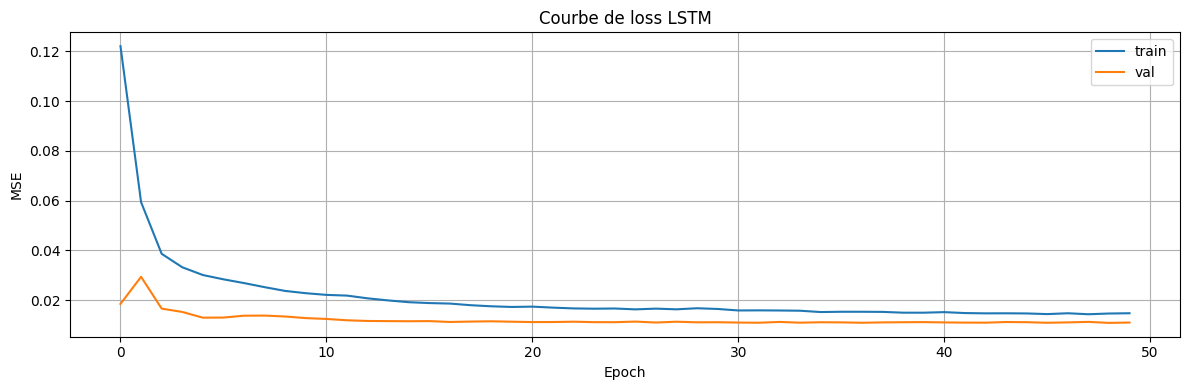

In [20]:
EPOCHS = 50
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    loss_ep = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        loss_ep += loss.item()
    train_losses.append(loss_ep / len(train_loader))

    model.eval()
    with torch.no_grad():
        val_loss = sum(criterion(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                       for xb, yb in test_loader) / len(test_loader)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  train_loss={train_losses[-1]:.5f}  val_loss={val_losses[-1]:.5f}")

# Courbe de loss
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Courbe de loss LSTM'); plt.legend()
plt.tight_layout(); plt.show()

## 4.7 Évaluation + visualisation

Baseline (LR)  →  MAE: 0.2964 kW  |  RMSE: 0.4299 kW
LSTM           →  MAE: 0.1870 kW  |  RMSE: 0.3025 kW


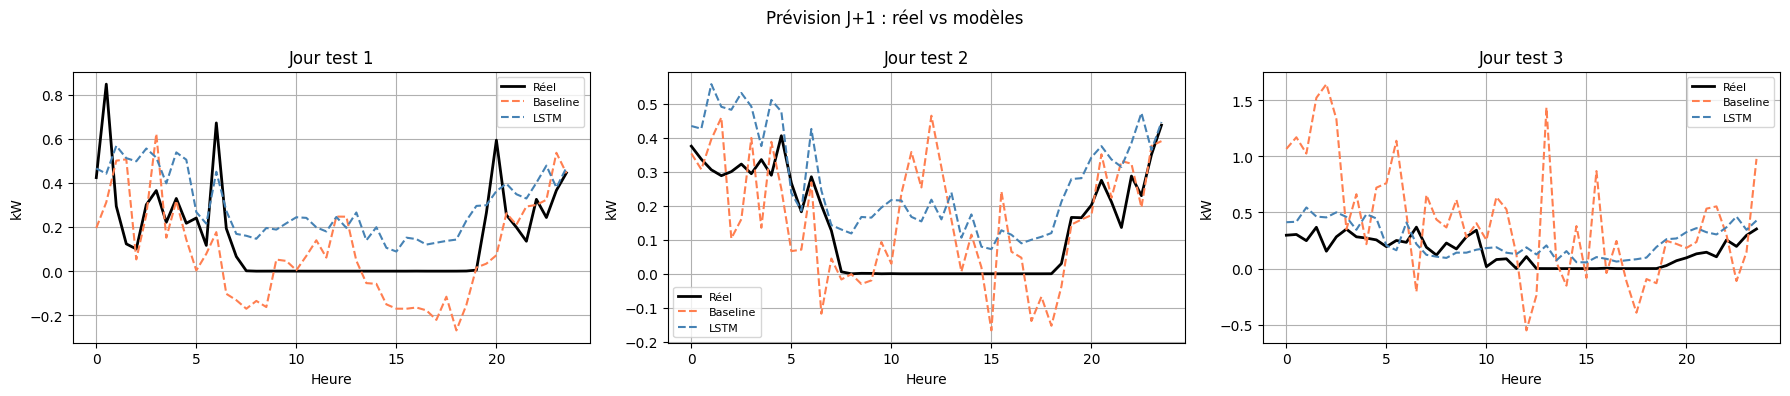

In [21]:
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        preds.append(model(xb.to(DEVICE)).cpu().numpy())

y_lstm_norm = np.vstack(preds)
y_lstm_kw = scaler_ts.inverse_transform(y_lstm_norm)
mae_lstm  = mean_absolute_error(y_test_kw.flatten(), y_lstm_kw.flatten())
rmse_lstm = np.sqrt(mean_squared_error(y_test_kw.flatten(), y_lstm_kw.flatten()))

print(f"Baseline (LR)  →  MAE: {mae_bl:.4f} kW  |  RMSE: {rmse_bl:.4f} kW")
print(f"LSTM           →  MAE: {mae_lstm:.4f} kW  |  RMSE: {rmse_lstm:.4f} kW")

# Visualise les 3 premiers jours de test
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, ax in enumerate(axes):
    t = np.arange(N_SLOTS) * 0.5
    ax.plot(t, y_test_kw[i],   label='Réel',     color='black', linewidth=2)
    ax.plot(t, y_bl_kw[i],     label='Baseline', color='coral',     linestyle='--')
    ax.plot(t, y_lstm_kw[i],   label='LSTM',     color='steelblue', linestyle='--')
    ax.set_title(f'Jour test {i+1}')
    ax.set_xlabel('Heure'); ax.set_ylabel('kW')
    ax.legend(fontsize=8)

plt.suptitle('Prévision J+1 : réel vs modèles', fontsize=12)
plt.tight_layout(); plt.show()

## 4.8 Sauvegarde

In [22]:
torch.save(model.state_dict(), '../models/lstm_forecaster.pt')
joblib.dump(scaler_ts, '../models/scaler_ts.pkl')

import json
with open('../models/forecast_meta.json', 'w') as f:
    json.dump({
        'client_id': str(client_id),
        'label': str(features.loc[client_id, 'label']),
        'window_days': WINDOW,
        'mae': mae_lstm,
        'rmse': rmse_lstm,
        'mae_baseline': mae_bl,
        'rmse_baseline': rmse_bl,
        'evaluation_scope': 'single representative client; extend to a panel for final presentation',
    }, f, indent=2)

print(f"Sauvegardé : lstm_forecaster.pt, scaler_ts.pkl, forecast_meta.json")


Sauvegardé : lstm_forecaster.pt, scaler_ts.pkl, forecast_meta.json


In [23]:
# ── Sélection de 10 clients : 5 RP + 5 RS avec le plus de jours actifs ──
rp_ids = features[features['label'] == 'RP'].nlargest(5, 'nb_jours_actifs').index
rs_ids = features[features['label'] == 'RS'].nlargest(5, 'nb_jours_actifs').index
client_ids = list(rp_ids) + list(rs_ids)

print("Clients sélectionnés :")
for cid in client_ids:
    print(f"  {cid}  {features.loc[cid, 'label']}  {features.loc[cid, 'nb_jours_actifs']:.0f} jours actifs")

# ── Hyperparamètres ──
N_SLOTS = 48
WINDOW  = 7
EPOCHS  = 50

# ── Définition du LSTM ──
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=48, hidden_size=64, num_layers=2, output_size=48):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

# ── Boucle principale ──
all_scores = []

for client_id in client_ids:
    label = features.loc[client_id, 'label']
    print(f"\n{'='*55}")
    print(f"Client {client_id}  [{label}]")

    # Préparation des séquences
    serie  = df_pivot.loc[client_id].values
    n_days = len(serie) // N_SLOTS
    matrix = serie[:n_days * N_SLOTS].reshape(n_days, N_SLOTS)

    scaler_ts   = MinMaxScaler()
    matrix_norm = scaler_ts.fit_transform(matrix)

    X_seq, y_seq = [], []
    for i in range(WINDOW, n_days):
        X_seq.append(matrix_norm[i-WINDOW:i])
        y_seq.append(matrix_norm[i])
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)

    # Split chronologique 80/20
    split = int(len(X_seq) * 0.8)
    X_train, X_test = X_seq[:split], X_seq[split:]
    y_train, y_test = y_seq[:split], y_seq[split:]

    y_test_kw = scaler_ts.inverse_transform(y_test)

    # ── Baseline linéaire ──
    X_bl_train = np.hstack([X_train[:, -1, :], X_train[:, -7, :]])
    X_bl_test  = np.hstack([X_test[:,  -1, :], X_test[:,  -7, :]])
    lr = LinearRegression()
    lr.fit(X_bl_train, y_train)
    y_bl_kw = scaler_ts.inverse_transform(lr.predict(X_bl_test))
    mae_bl  = mean_absolute_error(y_test_kw.flatten(), y_bl_kw.flatten())
    rmse_bl = np.sqrt(mean_squared_error(y_test_kw.flatten(), y_bl_kw.flatten()))

    # ── LSTM ──
    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
    test_loader  = DataLoader(TimeSeriesDataset(X_test,  y_test),  batch_size=32)

    model     = LSTMForecaster().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            preds.append(model(xb.to(DEVICE)).cpu().numpy())
    y_lstm_kw = scaler_ts.inverse_transform(np.vstack(preds))
    mae_lstm  = mean_absolute_error(y_test_kw.flatten(), y_lstm_kw.flatten())
    rmse_lstm = np.sqrt(mean_squared_error(y_test_kw.flatten(), y_lstm_kw.flatten()))

    print(f"  Baseline →  MAE: {mae_bl:.4f} kW  |  RMSE: {rmse_bl:.4f} kW")
    print(f"  LSTM     →  MAE: {mae_lstm:.4f} kW  |  RMSE: {rmse_lstm:.4f} kW")

    all_scores.append({
        'client_id': client_id,
        'label':     label,
        'n_days':    n_days,
        'mae_bl':    mae_bl,
        'rmse_bl':   rmse_bl,
        'mae_lstm':  mae_lstm,
        'rmse_lstm': rmse_lstm,
    })

# ── Résultats ──
df_scores = pd.DataFrame(all_scores).set_index('client_id')
print("\n\n" + "="*55)
print("SCORES PAR CLIENT")
print(df_scores.to_string())

print("\n\nMOYENNES PAR LABEL")
print(df_scores.groupby('label')[['mae_bl','rmse_bl','mae_lstm','rmse_lstm']].mean().round(4))

print("\n\nMOYENNES GLOBALES (10 clients)")
print(df_scores[['mae_bl','rmse_bl','mae_lstm','rmse_lstm']].mean().round(4))

print(f"\nGain LSTM vs Baseline (MAE) : {(1 - df_scores['mae_lstm'].mean() / df_scores['mae_bl'].mean())*100:.1f}%")

Clients sélectionnés :
  1704875583  RP  364 jours actifs
  10607320546  RP  364 jours actifs
  11239534806  RP  364 jours actifs
  14953875748  RP  364 jours actifs
  19987809609  RP  364 jours actifs
  407542367671  RS  358 jours actifs
  21164370115  RS  357 jours actifs
  857901669557  RS  351 jours actifs
  873655333875  RS  327 jours actifs
  16277393756  RS  326 jours actifs

Client 1704875583  [RP]
  Baseline →  MAE: 0.2964 kW  |  RMSE: 0.4299 kW
  LSTM     →  MAE: 0.1865 kW  |  RMSE: 0.3002 kW

Client 10607320546  [RP]
  Baseline →  MAE: 0.3842 kW  |  RMSE: 0.5412 kW
  LSTM     →  MAE: 0.3191 kW  |  RMSE: 0.4668 kW

Client 11239534806  [RP]
  Baseline →  MAE: 0.5106 kW  |  RMSE: 0.7902 kW
  LSTM     →  MAE: 0.2761 kW  |  RMSE: 0.4827 kW

Client 14953875748  [RP]
  Baseline →  MAE: 0.8229 kW  |  RMSE: 1.0864 kW
  LSTM     →  MAE: 0.5309 kW  |  RMSE: 0.6915 kW

Client 19987809609  [RP]
  Baseline →  MAE: 0.4660 kW  |  RMSE: 0.6529 kW
  LSTM     →  MAE: 0.2412 kW  |  RMSE: 0.4808